In [1]:
import json
import time
import numpy as np
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
import sys
sys.path.append(r"E:\PythonPrograms\VAE_MEN_WOMEN\Model")
from models_lstm import build_encoder_lstm, build_decoder_lstm, LSTM_VAE, Sampling

In [3]:
ROOT = Path(r"E:\marcel.furs\Documents\Data_Run_Walk\Data_Run_Walk")

print("TF version:", tf.__version__)
print("ROOT exists:", ROOT.exists())
print("Import LSTM-VAE: OK")

TF version: 2.20.0
ROOT exists: True
Import LSTM-VAE: OK


In [4]:
BATCH_SIZE    = 32
LEARNING_RATE = 1e-3
EPOCHS        = 1000
PATIENCE      = 15

In [5]:
ROOT_Exp = "exp1a_train_M_detect_F"   # M F
EXP_DIR  = ROOT / "EXPERIMENTS" / ROOT_Exp

X_train_paper  = np.load(EXP_DIR / "X_train.npy")
X_val_paper    = np.load(EXP_DIR / "X_val.npy")
X_test_normal  = np.load(EXP_DIR / "X_test_normal.npy")
X_test_anomaly = np.load(EXP_DIR / "X_test_anomaly.npy")
subj_train = np.load(EXP_DIR / "subjects_train.npy", allow_pickle=True)
subj_val   = np.load(EXP_DIR / "subjects_val.npy", allow_pickle=True)

X_S1_normal    = np.concatenate([X_train_paper, X_val_paper])
subj_S1_normal = np.concatenate([subj_train, subj_val])

print("Shape:", X_S1_normal.shape, X_test_normal.shape, X_test_anomaly.shape)

Shape: (96, 100, 26, 3) (94, 100, 26, 3) (235, 100, 26, 3)


In [6]:
if X_S1_normal.ndim == 2:                          # (n, 7800) → (n, 100, 78)
    X_S1_normal    = X_S1_normal.reshape(-1, 100, 78)
    X_test_normal  = X_test_normal.reshape(-1, 100, 78)
    X_test_anomaly = X_test_anomaly.reshape(-1, 100, 78)
elif X_S1_normal.ndim == 4:                        # (n, 100, 26, 3) → (n, 100, 78)
    X_S1_normal    = X_S1_normal.reshape(X_S1_normal.shape[0], 100, -1)
    X_test_normal  = X_test_normal.reshape(X_test_normal.shape[0], 100, -1)
    X_test_anomaly = X_test_anomaly.reshape(X_test_anomaly.shape[0], 100, -1)

print("Po reshape:", X_S1_normal.shape, X_test_normal.shape, X_test_anomaly.shape)


Po reshape: (96, 100, 78) (94, 100, 78) (235, 100, 78)


In [7]:
def make_split(X_normal_S1, subj_normal_S1, seed):
    """Per-subject 80/20 split — train/val nie dzielą subjects."""
    unique_subj = np.unique(subj_normal_S1)
    n_val = max(1, int(len(unique_subj) * 0.2))
    rng = np.random.RandomState(seed)
    val_subj = rng.choice(unique_subj, size=n_val, replace=False)
    train_subj = np.array([s for s in unique_subj if s not in val_subj])
    mask_tr = np.isin(subj_normal_S1, train_subj)
    mask_va = np.isin(subj_normal_S1, val_subj)
    return X_normal_S1[mask_tr], X_normal_S1[mask_va]

print("make_split loaded")

make_split loaded


In [8]:
seed = 0
tf.random.set_seed(seed)
np.random.seed(seed)
X_tr, X_va = make_split(X_S1_normal, subj_S1_normal, seed=seed)
print(f"Train: {X_tr.shape}, Val: {X_va.shape}")

# === 5. STANDARYZACJA (fit na train, transform na pozostałych) ===
n_train, T, F = X_tr.shape
scaler = StandardScaler()
X_train_norm        = scaler.fit_transform(X_tr.reshape(n_train, -1)).reshape(n_train, T, F)
X_val_norm          = scaler.transform(X_va.reshape(len(X_va), -1)).reshape(-1, T, F)
X_test_normal_norm  = scaler.transform(X_test_normal.reshape(len(X_test_normal), -1)).reshape(-1, T, F)
X_test_anomaly_norm = scaler.transform(X_test_anomaly.reshape(len(X_test_anomaly), -1)).reshape(-1, T, F)

Train: (79, 100, 78), Val: (17, 100, 78)


In [9]:
encoder = build_encoder_lstm(seq_len=T, n_features=F)
decoder = build_decoder_lstm(seq_len=T, n_features=F)
vae = LSTM_VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE, clipnorm=1.0))

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

In [11]:
t0 = time.time()
history = vae.fit(
    X_train_norm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(X_val_norm, None),
    callbacks=[early_stop],
    verbose=1,
)
print(f"\nCzas treningu: {(time.time()-t0)/60:.1f} min, epok: {len(history.history['loss'])}")


Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 910ms/step - kl: 0.6576 - loss: 1.0290 - mse: 1.0224 - val_kl: 0.4423 - val_loss: 1.2624 - val_mse: 1.2580
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - kl: 0.5551 - loss: 1.0144 - mse: 1.0089 - val_kl: 0.4761 - val_loss: 1.2504 - val_mse: 1.2456
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - kl: 0.5882 - loss: 1.0022 - mse: 0.9964 - val_kl: 0.5327 - val_loss: 1.2481 - val_mse: 1.2428
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - kl: 0.8405 - loss: 1.0011 - mse: 0.9927 - val_kl: 0.6315 - val_loss: 1.2406 - val_mse: 1.2343
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - kl: 1.0249 - loss: 0.9819 - mse: 0.9716 - val_kl: 0.7553 - val_loss: 1.2430 - val_mse: 1.2354
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - kl: 1.3318 - loss: 0.9568 - mse: 0.9435 - val_kl: 0.9459 - val_loss: 1.2267 - val_mse: 1.2172
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - kl: 1.8817 - loss: 0.9325 - mse: 0.9137 - val_kl: 1.2355 

In [12]:
def compute_mse(model, X):
    mu, logvar, z = model.encoder.predict(X, verbose=0)
    X_recon = model.decoder.predict(z, verbose=0)
    return np.mean((X - X_recon)**2, axis=(1, 2))   # 3D → axis=(1,2)

mse_test_normal  = compute_mse(vae, X_test_normal_norm)
mse_test_anomaly = compute_mse(vae, X_test_anomaly_norm)

y_true  = np.concatenate([np.zeros(len(mse_test_normal)),
                          np.ones(len(mse_test_anomaly))])
y_score = np.concatenate([mse_test_normal, mse_test_anomaly])

auc = roc_auc_score(y_true, y_score)
ap  = average_precision_score(y_true, y_score)
separation = mse_test_anomaly.mean() / mse_test_normal.mean()

print(f"\nAUC: {auc:.3f}")
print(f"AP:  {ap:.3f}")
print(f"Separation (F/M): {separation:.3f}x")


AUC: 0.875
AP:  0.924
Separation (F/M): 1.697x


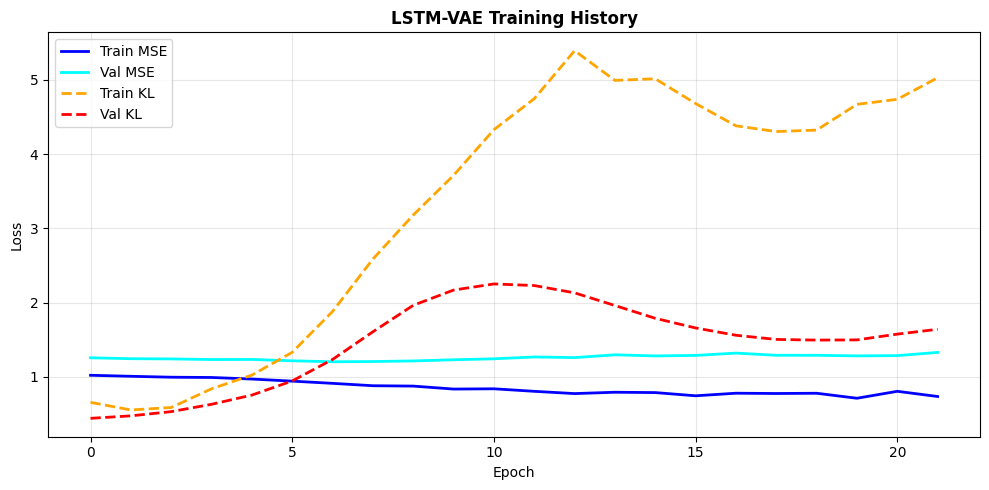

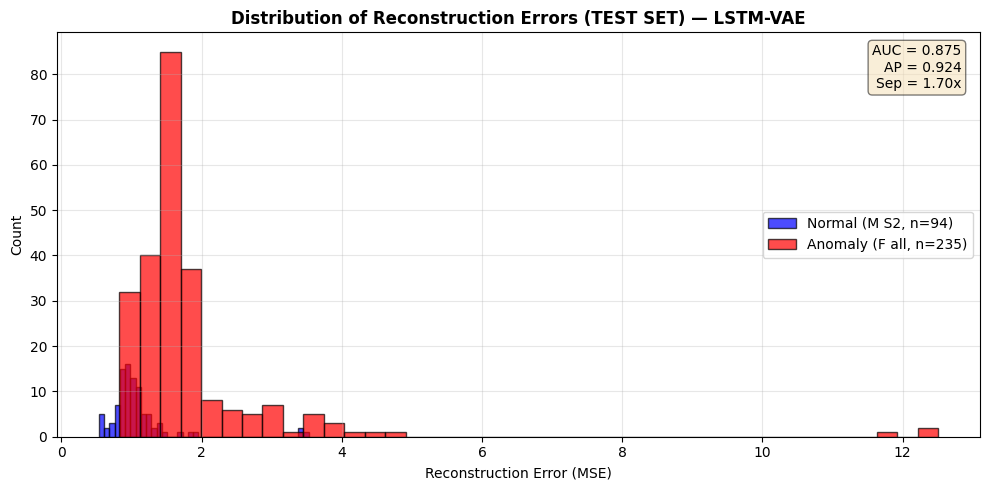

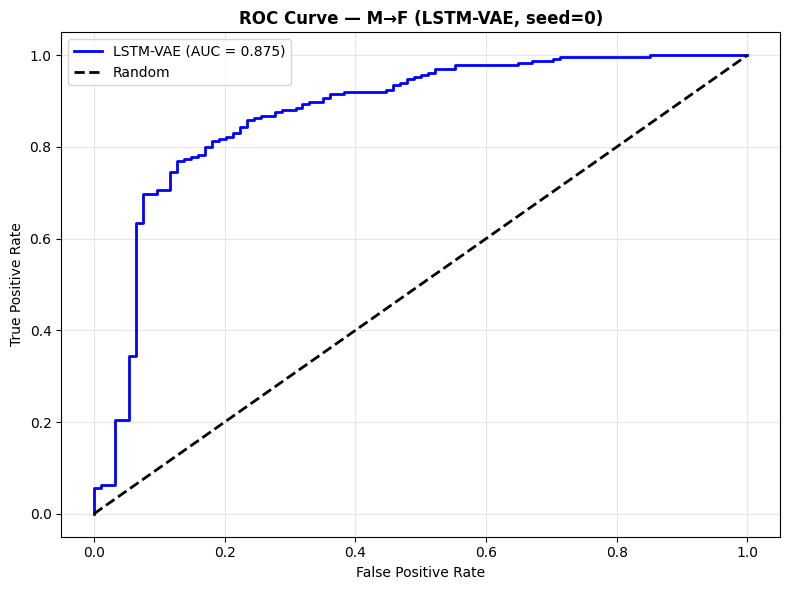

In [13]:
# Training history
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["mse"], label="Train MSE", linewidth=2, color='blue')
ax.plot(history.history["val_mse"], label="Val MSE", linewidth=2, color='cyan')
ax.plot(history.history["kl"], label="Train KL", linewidth=2, linestyle='--', color='orange')
ax.plot(history.history["val_kl"], label="Val KL", linewidth=2, linestyle='--', color='red')
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("LSTM-VAE Training History", fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(mse_test_normal,  bins=40, alpha=0.7, color='blue', edgecolor='black',
         label=f'Normal (M S2, n={len(mse_test_normal)})')
plt.hist(mse_test_anomaly, bins=40, alpha=0.7, color='red',  edgecolor='black',
         label=f'Anomaly (F all, n={len(mse_test_anomaly)})')
plt.xlabel('Reconstruction Error (MSE)'); plt.ylabel('Count')
plt.title('Distribution of Reconstruction Errors (TEST SET) — LSTM-VAE', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.text(0.98, 0.97, f'AUC = {auc:.3f}\nAP = {ap:.3f}\nSep = {separation:.2f}x',
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout(); plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, color='blue', label=f'LSTM-VAE (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — M→F (LSTM-VAE, seed=0)', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
def save_result_v2(
    experiment,           # 'sex' / 'speed' / 'walk_run'
    direction,            # 'M_to_F' / etc.
    config,               # 'A' / 'B' / None (dla baseline'ów które nie mają config)
    model,                # 'dense_VAE' / 'PCA' / 'OC_SVM' / 'IF' / 'LSTM_VAE'
    hyperparameters,      # dict: np. {"n_components": 4} albo {"latent_dim": 4, "width": 128, ...}
    data_info,            # dict: {"root_exp": str, "s1_pool": int, "s2_normal": int, "s2_anomaly": int, "n_features": int}
    aucs, aps,            # listy 30 wartości
    seeds,                # lista użytych seedów
    duration_s,           # czas całego batcha
    notes="",             # opcjonalna notatka tekstowa
    results_path="results_v2.json"
):
    entry = {
        "experiment": experiment,
        "direction": direction,
        "config": config,
        "model": model,
        "hyperparameters": hyperparameters,
        "data_info": data_info,
        "n_splits": len(aucs),
        "seeds": list(seeds),
        "aucs": list(map(float, aucs)),
        "aps":  list(map(float, aps)),
        "auc_mean": float(np.mean(aucs)),
        "auc_std":  float(np.std(aucs)),
        "ap_mean":  float(np.mean(aps)),
        "ap_std":   float(np.std(aps)),
        "duration_s": float(duration_s),
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "notes": notes,
    }
    if Path(results_path).exists():
        with open(results_path) as f:
            all_results = json.load(f)
    else:
        all_results = []
    # dedup key uwzględnia też hyperparameters (różne n_components = różne wpisy)
    def hp_key(hp):
        return tuple(sorted(hp.items()))
    key = (experiment, direction, config, model, hp_key(hyperparameters))
    all_results = [r for r in all_results
                   if (r["experiment"], r["direction"], r["config"], r["model"],
                       hp_key(r["hyperparameters"])) != key]
    all_results.append(entry)
    with open(results_path, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f" zapisano: {experiment}/{direction}/{config or '-'}/{model}/{hp_key(hyperparameters)}")

In [16]:
N_SPLITS = 30
SEEDS = list(range(N_SPLITS))

MODEL_NAME = "LSTM_VAE"
HYPERPARAMS = {
    "hidden_dim": 64, "latent_dim": 4, "dropout": 0.2,
    "beta_kl": 0.01, "batch_size": 32, "learning_rate": 1e-3,
    "epochs_max": 1000, "patience": 30,
    "architecture": "LSTM (single layer)", "clipnorm": 1.0
}
CONFIG = "A"
NOTES = "LSTM-VAE for architecture comparison vs Dense VAE (R2-2)"

EXPERIMENTS_LSTM = [
    #("sex", "M_to_F", "exp1a_train_M_detect_F"),
    #("sex", "F_to_M", "exp1b_train_F_detect_M"),
    ("speed", "Slow_to_Fast", "exp_train_slow_detect_fast"),
    ("speed", "Fast_to_Slow", "exp_train_fast_detect_slow"),
]

t_total = time.time()

for experiment, direction, root_exp in EXPERIMENTS_LSTM:
    print(f"\n{'='*70}")
    print(f"  {experiment} / {direction}  (folder: {root_exp})")
    print('='*70)
    EXP_DIR = ROOT / "EXPERIMENTS" / root_exp

    # load
    X_train_paper  = np.load(EXP_DIR / "X_train.npy")
    X_val_paper    = np.load(EXP_DIR / "X_val.npy")
    X_test_normal  = np.load(EXP_DIR / "X_test_normal.npy")
    X_test_anomaly = np.load(EXP_DIR / "X_test_anomaly.npy")
    subj_train = np.load(EXP_DIR / "subjects_train.npy", allow_pickle=True)
    subj_val   = np.load(EXP_DIR / "subjects_val.npy", allow_pickle=True)
    X_S1_normal    = np.concatenate([X_train_paper, X_val_paper])
    subj_S1_normal = np.concatenate([subj_train, subj_val])

    # reshape jeśli trzeba
    if X_S1_normal.ndim == 2:
        X_S1_normal    = X_S1_normal.reshape(-1, 100, 78)
        X_test_normal  = X_test_normal.reshape(-1, 100, 78)
        X_test_anomaly = X_test_anomaly.reshape(-1, 100, 78)
    elif X_S1_normal.ndim == 4:
        X_S1_normal    = X_S1_normal.reshape(X_S1_normal.shape[0], 100, -1)
        X_test_normal  = X_test_normal.reshape(X_test_normal.shape[0], 100, -1)
        X_test_anomaly = X_test_anomaly.reshape(X_test_anomaly.shape[0], 100, -1)

    data_info = {
        "root_exp": root_exp,
        "s1_pool": int(X_S1_normal.shape[0]),
        "s2_normal": int(X_test_normal.shape[0]),
        "s2_anomaly": int(X_test_anomaly.shape[0]),
        "input_shape": list(X_S1_normal.shape[1:]),
        "n_features_flat": int(np.prod(X_S1_normal.shape[1:])),
        "n_unique_subjects_s1": int(len(np.unique(subj_S1_normal))),
    }
    print(f"  S1 pool: {data_info['s1_pool']}, "
          f"S2 normal: {data_info['s2_normal']}, anomaly: {data_info['s2_anomaly']}")

    results = []
    t0 = time.time()
    for s in SEEDS:
        tf.random.set_seed(s)
        np.random.seed(s)

        X_tr, X_va = make_split(X_S1_normal, subj_S1_normal, seed=s)

        # standaryzacja
        n_train, T, F = X_tr.shape
        scaler = StandardScaler()
        X_tr_n = scaler.fit_transform(X_tr.reshape(n_train, -1)).reshape(n_train, T, F)
        X_va_n = scaler.transform(X_va.reshape(len(X_va), -1)).reshape(-1, T, F)
        X_tn_n = scaler.transform(X_test_normal.reshape(len(X_test_normal), -1)).reshape(-1, T, F)
        X_ta_n = scaler.transform(X_test_anomaly.reshape(len(X_test_anomaly), -1)).reshape(-1, T, F)

        # build & train
        encoder = build_encoder_lstm(seq_len=T, n_features=F)
        decoder = build_decoder_lstm(seq_len=T, n_features=F)
        vae = LSTM_VAE(encoder, decoder)
        vae.compile(optimizer=keras.optimizers.Adam(HYPERPARAMS["learning_rate"], clipnorm=1.0))

        es = keras.callbacks.EarlyStopping(monitor="val_loss",
                                           patience=HYPERPARAMS["patience"],
                                           restore_best_weights=True, verbose=0)
        vae.fit(X_tr_n,
                epochs=HYPERPARAMS["epochs_max"],
                batch_size=HYPERPARAMS["batch_size"],
                shuffle=True,
                validation_data=(X_va_n, None),
                callbacks=[es], verbose=0)

        # scoring
        def compute_mse(model, X):
            mu, logvar, z = model.encoder.predict(X, verbose=0)
            recon = model.decoder.predict(z, verbose=0)
            return np.mean((X - recon)**2, axis=(1, 2))

        score_n = compute_mse(vae, X_tn_n)
        score_a = compute_mse(vae, X_ta_n)
        y_true  = np.concatenate([np.zeros(len(score_n)), np.ones(len(score_a))])
        y_score = np.concatenate([score_n, score_a])
        auc = float(roc_auc_score(y_true, y_score))
        ap  = float(average_precision_score(y_true, y_score))

        results.append({"auc": auc, "ap": ap})

        elapsed = time.time() - t0
        eta = elapsed / (s + 1) * (N_SPLITS - s - 1)
        print(f"    seed {s+1:2d}/{N_SPLITS}: AUC={auc:.3f} | "
              f"elapsed: {elapsed/60:.1f}min, ETA: {eta/60:.1f}min")

        # cleanup żeby pamięć nie eksplodowała
        del encoder, decoder, vae
        tf.keras.backend.clear_session()

    duration = time.time() - t0
    aucs = [r["auc"] for r in results]
    aps  = [r["ap"]  for r in results]
    print(f"\n  KOŃCOWY: AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f} | "
          f"AP: {np.mean(aps):.3f} ± {np.std(aps):.3f}")
    print(f"  Czas: {duration/60:.1f} min")

    save_result_v2(
        experiment=experiment, direction=direction, config=CONFIG,
        model=MODEL_NAME, hyperparameters=HYPERPARAMS, data_info=data_info,
        aucs=aucs, aps=aps, seeds=SEEDS, duration_s=duration, notes=NOTES,
    )

print(f"\n{'='*70}\nTOTAL TIME: {(time.time()-t_total)/60:.1f} min")


  speed / Slow_to_Fast  (folder: exp_train_slow_detect_fast)
  S1 pool: 219, S2 normal: 197, anomaly: 417
    seed  1/30: AUC=0.858 | elapsed: 0.7min, ETA: 21.6min
    seed  2/30: AUC=0.837 | elapsed: 1.8min, ETA: 24.8min
    seed  3/30: AUC=0.839 | elapsed: 2.7min, ETA: 23.9min
    seed  4/30: AUC=0.847 | elapsed: 3.6min, ETA: 23.5min
    seed  5/30: AUC=0.839 | elapsed: 4.6min, ETA: 23.1min
    seed  6/30: AUC=0.831 | elapsed: 5.7min, ETA: 22.9min
    seed  7/30: AUC=0.853 | elapsed: 6.7min, ETA: 21.9min
    seed  8/30: AUC=0.777 | elapsed: 8.3min, ETA: 22.7min
    seed  9/30: AUC=0.840 | elapsed: 9.3min, ETA: 21.7min
    seed 10/30: AUC=0.844 | elapsed: 10.6min, ETA: 21.2min
    seed 11/30: AUC=0.826 | elapsed: 11.8min, ETA: 20.4min
    seed 12/30: AUC=0.855 | elapsed: 12.8min, ETA: 19.2min
    seed 13/30: AUC=0.803 | elapsed: 13.9min, ETA: 18.1min
    seed 14/30: AUC=0.823 | elapsed: 15.1min, ETA: 17.2min
    seed 15/30: AUC=0.793 | elapsed: 16.5min, ETA: 16.5min
    seed 16/30: A